In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import tensorflow as tf
from datetime import datetime
from sklearn.decomposition import PCA
pd.set_option('display.max_rows', None)

In [ ]:
"""train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')"""
train = pd.read_parquet('data/trainprep.parquet')
test = pd.read_parquet('data/testprep.parquet')
val = pd.read_parquet('data/valprep.parquet')

In [33]:
train.columns

Index(['Attack ID', 'Attack code_x', 'Avg source IP count', 'Start time',
       'End time', 'Type', 'Detect count_y', 'Victim IP_y', 'Port number_y',
       'Attack code_y', 'Packet speed_y', 'Data speed_y', 'Avg packet len_y',
       'Source IP count', 'Packet speed_y_normalized',
       'Data speed_y_normalized', 'Avg packet len_y_normalized'],
      dtype='object')

In [34]:
train.drop(columns=['Attack code_y'], inplace=True)
test.drop(columns=['Attack code_y'], inplace=True)
val.drop(columns=['Attack code_y'], inplace=True)

In [35]:
train.columns

Index(['Attack ID', 'Attack code_x', 'Avg source IP count', 'Start time',
       'End time', 'Type', 'Detect count_y', 'Victim IP_y', 'Port number_y',
       'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count',
       'Packet speed_y_normalized', 'Data speed_y_normalized',
       'Avg packet len_y_normalized'],
      dtype='object')

In [36]:
dataframes = [train, test, val]
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 0
    elif 12 <= hour < 17:
        return 1
    elif 17 <= hour < 21:
        return 2
    else:
        return 3

for df in dataframes:
    df['Start time'] = pd.to_datetime(df['Start time'], format='mixed')
    df['End time'] = pd.to_datetime(df['End time'], format='mixed')
    df['total_seconds'] = (df['End time'] - df['Start time']).dt.total_seconds()
    df['weekday_number'] = df['Start time'].dt.weekday
    df['time_of_day'] = df['Start time'].dt.hour.apply(get_time_of_day)

    df['IsWeekend'] = df['weekday_number'].apply(lambda x: 1 if x >= 5 else 0)
    df['Start Hour'] = pd.to_datetime(df['Start time']).dt.hour

    # Convert hour into cyclic features
    df['Sin_Hour'] = np.sin(2 * np.pi * df['Start Hour'] / 24)
    df['Cos_Hour'] = np.cos(2 * np.pi * df['Start Hour'] / 24)

    # Convert date into cyclic features
    df['DayOfYear'] = pd.to_datetime(df['Start time']).dt.dayofyear
    df['Sin_DayOfYear'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
    df['Cos_DayOfYear'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

    # Statistical features based on 'DataSpeed' and 'DetectCount'
    df['Mean_DataSpeed'] = df.groupby('Attack ID')['Data speed_y'].transform('mean')
    df['Std_DataSpeed'] = df.groupby('Attack ID')['Data speed_y'].transform('std')
    df['Min_DataSpeed'] = df.groupby('Attack ID')['Data speed_y'].transform('min')
    df['Max_DataSpeed'] = df.groupby('Attack ID')['Data speed_y'].transform('max')

    df['Mean_PacketSpeed'] = df.groupby('Attack ID')['Packet speed_y'].transform('mean')
    df['Std_PacketSpeed'] = df.groupby('Attack ID')['Packet speed_y'].transform('std')
    df['Min_PacketSpeed'] = df.groupby('Attack ID')['Packet speed_y'].transform('min')
    df['Max_PacketSpeed'] = df.groupby('Attack ID')['Packet speed_y'].transform('max')

    df['Mean_DetectCount'] = df.groupby('Attack ID')['Detect count_y'].transform('mean')
    df['Std_DetectCount'] = df.groupby('Attack ID')['Detect count_y'].transform('std')
    df['Min_DetectCount'] = df.groupby('Attack ID')['Detect count_y'].transform('min')
    df['Max_DetectCount'] = df.groupby('Attack ID')['Detect count_y'].transform('max')

    # New features based on 'Victim IP_y', 'Port number_y', and 'Avg packet len_normalized'
    df['VictimIP_Count'] = df.groupby('Victim IP_y')['Victim IP_y'].transform('count')
    df['PortNumber_Count'] = df.groupby('Port number_y')['Port number_y'].transform('count')
    df['AvgPacketLen_Mean'] = df.groupby('Attack ID')['Avg packet len_y_normalized'].transform('mean')
    df['AvgPacketLen_Std'] = df.groupby('Attack ID')['Avg packet len_y_normalized'].transform('std')

    # New feature: DataSpeed * PacketSpeed
    df['DataSpeed_PacketSpeed'] = df['Data speed_y'] * df['Packet speed_y']

    # New feature: Port frequency
    df['PortFrequency'] = df.groupby('Port number_y')['Port number_y'].transform('count') / len(df)

In [37]:
for df in [train, test, val]:
    for col in ['Std_DataSpeed', 'Std_DetectCount', 'AvgPacketLen_Std']:
        indicator_col = f'{col}_Replaced'
        df[indicator_col] = df[col].isna().astype(int)  # 1 if NaN, 0 otherwise
        df[col] = df[col].fillna(0)  # Replace NaN with 0

In [38]:
# Repeat for test and validation datasets if applicable
for df in [train, test, val]:
    df["total_seconds"].replace([-88, 0], 0.1, inplace=True)

    df["packet_Total"] = df["Packet speed_y_normalized"] * df["Avg packet len_y_normalized"]

    # Create new features based on ratios
    df['PacketSpeed_Per_Second'] = df['Packet speed_y_normalized'] / df['total_seconds']
    df['AvgPacketLen_Per_DataSpeed'] = df['Avg packet len_y_normalized'] / df['Data speed_y_normalized']

    # Handle potential division by zero
    df['PacketSpeed_Per_Second'].replace([np.inf, -np.inf], 0, inplace=True)
    df['AvgPacketLen_Per_DataSpeed'].replace([np.inf, -np.inf], 0, inplace=True)

    # Create other ratio-based features
    df['DataSpeed_Per_TotalSeconds'] = df['Data speed_y_normalized'] / df['total_seconds']
    df['AvgPacketLen_Per_TotalSeconds'] = df['Avg packet len_y_normalized'] / df['total_seconds']

    # Handle potential division by zero for new features
    df['DataSpeed_Per_TotalSeconds'].replace([np.inf, -np.inf], 0, inplace=True)
    df['AvgPacketLen_Per_TotalSeconds'].replace([np.inf, -np.inf], 0, inplace=True)

    df['PacketSpeed_Per_Second'] = df['Packet speed_y_normalized'] / df['total_seconds']
    df['AvgPacketLen_Per_DataSpeed'] = df['Avg packet len_y_normalized'] / df['Data speed_y_normalized']
    df['DataSpeed_Per_TotalSeconds'] = df['Data speed_y_normalized'] / df['total_seconds']
    df['AvgPacketLen_Per_TotalSeconds'] = df['Avg packet len_y_normalized'] / df['total_seconds']
    
    # Handle division by zero
    for col in ['PacketSpeed_Per_Second', 'AvgPacketLen_Per_DataSpeed', 
                'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds']:
        df[col].replace([np.inf, -np.inf], 0, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16644\2610249317.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_seconds"].replace([-88, 0], 0.1, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16644\2610249317.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [18]:
protocol_ports_extensive = {
    'Is_HTTP': 80,
    'Is_HTTPS': 443,
    'Is_FTP_Control': 21,
    'Is_FTP_Data': 20,
    'Is_SSH': 22,
    'Is_Telnet': 23,
    'Is_SMTP': 25,
    'Is_DNS': 53,
    'Is_POP3': 110,
    'Is_IMAP': 143,
    'Is_DHCP': [67, 68],
    'Is_SNMP': [161, 162],
    'Is_LDAP': 389,
    'Is_LDAPS': 636,
    'Is_SMB_CIFS': 445,
    'Is_RDP': 3389,
    'Is_SIP': [5060, 5061],
    'Is_TFTP': 69,
    'Is_MySQL': 3306,
    'Is_PostgreSQL': 5432,
    'Is_Oracle': 1521,
    'Is_HTTP_Alt_8080': 8080,
    'Is_HTTP_Alt_8081': 8081,
    'Is_HTTP_Alt_80': range(8000, 8089),  # Broader range
    'Is_HTTPS_Alt_8443': 8443,
    'Is_Syslog': 514,
    'Is_VNC': 5900,
    'Is_IRC': 6667,
    'Is_NTP': 123,
    'Is_Kerberos': [88, 749, 750, 464],
    'Is_LDAP_Alt': 3268,
    'Is_LDAPS_Alt': 3269,
    'Is_RADIUS': [1812, 1813],
    'Is_PPTP': 1723,
    'Is_RTSP': 554,
    'Is_X11': range(6000, 6064),
    'Is_SNMP_Trap': 162,
    'Is_BGP': 179,
    'Is_IMAPS_Alt': 993,
    'Is_POP3S_Alt': 995,
    'Is_Telnet_SSL': 992,
    'Is_NNTP': 119,
    'Is_NNTPS': 563,
    'Is_LDAP_TLS': 636,
    'Is_AFS': 2049,
    'Is_NFS': 2049,
    'Is_SOCKS': [1080, 1081],
    'Is_RSYNC': 873,
    'Is_CUPS': 631,
    'Is_TFTP_Alt': 69, # Already present, but for clarity
    'Is_Modbus': 502,
    'Is_CoAP': [5683, 5684],
    'Is_MQTT': [1883, 8883],
    'Is_AMQP': 5672,
    'Is_Redis': 6379,
    'Is_Memcached': 11211,
    'Is_Elasticsearch': [9200, 9300],
    'Is_Zookeeper': 2181,
    'Is_Cassandra': 9042,
    'Is_Docker': 2375,
    'Is_Kubernetes': 6443,
    'Is_SMB_Direct': 445, # Already present
    'Is_iSCSI': 3260,
    'Is_AFP': 548,
    'Is_DHCPv6': [546, 547],
    'Is_RIPng': 521,
    'Is_OSPF': 89,
    'Is_PPPoE': 3544,
    'Is_L2TP': 1701,
    'Is_GRE': 47, # Protocol number, not TCP/UDP port
    'Is_ESP': 50, # Protocol number
    'Is_AH': 51  # Protocol number
    # Add even more as needed
}

# Create the binary categorical features
for protocol, ports in protocol_ports_extensive.items():
    if isinstance(ports, int):
        train[protocol] = (train['Port number_y'] == ports)
    elif isinstance(ports, list):
        train[protocol] = train['Port number_y'].isin(ports)
    elif isinstance(ports, range):
        train[protocol] = train['Port number_y'].isin(ports)
    else:
        print(f"Warning: Unexpected port type for {protocol}")

for protocol, ports in protocol_ports_extensive.items():
    if isinstance(ports, int):
        test[protocol] = (test['Port number_y'] == ports)
    elif isinstance(ports, list):
        test[protocol] = test['Port number_y'].isin(ports)
    elif isinstance(ports, range):
        test[protocol] = test['Port number_y'].isin(ports)
    else:
        print(f"Warning: Unexpected port type for {protocol}")

for protocol, ports in protocol_ports_extensive.items():
    if isinstance(ports, int):
        val[protocol] = (val['Port number_y'] == ports)
    elif isinstance(ports, list):
        val[protocol] = val['Port number_y'].isin(ports)
    elif isinstance(ports, range):
        val[protocol] = val['Port number_y'].isin(ports)
    else:
        print(f"Warning: Unexpected port type for {protocol}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16644\1485513723.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[protocol] = (train['Port number_y'] == ports)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16644\1485513723.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[protocol] = (train['Port number_y'] == ports)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16644\1485513723.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

In [19]:
print(list(train.columns))

['Attack ID', 'Attack code_x', 'Avg source IP count', 'Start time', 'End time', 'Type', 'Detect count_y', 'Victim IP_y', 'Port number_y', 'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 'Packet speed_y_normalized', 'Data speed_y_normalized', 'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Std_PacketSpeed', 'Min_PacketSpeed', 'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 'AvgPacketLen_Per_DataSpeed', 'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSe

In [ ]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds',  'Is_HTTP', 
          'Is_HTTPS', 'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [40]:
# Apply PCA
pca = PCA(n_components=5, random_state=42)
train_pca = pca.fit_transform(train[x_cols].fillna(0))
test_pca = pca.transform(test[x_cols].fillna(0))
val_pca = pca.transform(val[x_cols].fillna(0))

# Convert PCA results to DataFrame
train_pca_df = pd.DataFrame(train_pca, columns=[f'PCA_{i+1}' for i in range(5)])
test_pca_df = pd.DataFrame(test_pca, columns=[f'PCA_{i+1}' for i in range(5)])
val_pca_df = pd.DataFrame(val_pca, columns=[f'PCA_{i+1}' for i in range(5)])

# Concatenate PCA results with original DataFrames
train = pd.concat([train, train_pca_df], axis=1)
test = pd.concat([test, test_pca_df], axis=1)
val = pd.concat([val, val_pca_df], axis=1)

In [ ]:
train.to_parquet('data/train.parquet', index=False)
test.to_parquet('data/test.parquet', index=False)
val.to_parquet('data/val.parquet', index=False)

In [ ]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [42]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the Random Forest classifier
rfc = RandomForestClassifier(n_estimators=250, random_state=42, max_depth=10, verbose=1)

# Train the classifier on the training data
rfc.fit(train[x_cols], train['Type'])

# Predict the labels for the test data
test['pred'] = rfc.predict(test[x_cols])

accuracy = accuracy_score(test['Type'], test['pred'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Type'], test['pred'], average='macro')
print("F1-Score:", f1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.1min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 12.3min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    7.5s


Accuracy: 0.8082053066466977
Precision: 0.8248274841215325
Recall: 0.5264244509243801
F1-Score: 0.5730233079450247


In [43]:
feature_importances = pd.Series(rfc.feature_importances_, index=x_cols)
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
Avg source IP count              0.071159
Std_DetectCount                  0.067611
Max_DetectCount                  0.066562
Std_DataSpeed                    0.054973
Mean_DetectCount                 0.054912
Source IP count                  0.053342
Mean_DataSpeed                   0.043590
Min_DataSpeed                    0.040355
Sin_DayOfYear                    0.037352
total_seconds                    0.035770
DayOfYear                        0.031821
AvgPacketLen_Mean                0.031463
AvgPacketLen_Std                 0.029690
Start Hour                       0.028557
Cos_DayOfYear                    0.027120
Max_DataSpeed                    0.026526
PCA_3                            0.026146
AvgPacketLen_Per_TotalSeconds    0.022111
Data speed_y_normalized          0.021298
Victim IP_y                      0.018429
VictimIP_Count                   0.018096
Data speed_y                     0.017270
Sin_Hour                         0.016993
PCA_5        

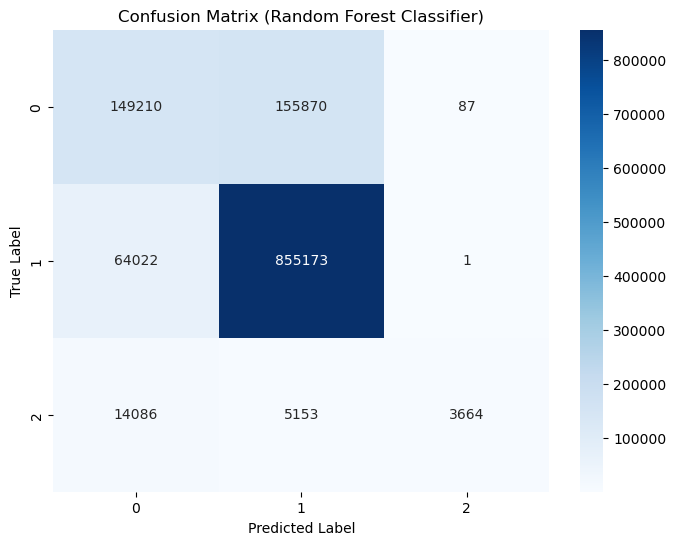

Confusion Matrix (Random Forest Classifier):
 [[149210 155870     87]
 [ 64022 855173      1]
 [ 14086   5153   3664]]


In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(test['Type'], test['pred'])

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(test['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [45]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(test['pred'], test['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.49      0.66      0.56    227318
           1       0.93      0.84      0.88   1016196
           2       0.16      0.98      0.27      3752

    accuracy                           0.81   1247266
   macro avg       0.53      0.82      0.57   1247266
weighted avg       0.85      0.81      0.82   1247266



In [46]:
# RFC
"""Accuracy: 0.804335242041393
Precision: 0.8319716584081629
Recall: 0.5070722787847076
F1-Score: 0.5624551255812759"""

# GBC
"""Accuracy: 0.8071077059745074
Precision: 0.6415983534051602
Recall: 0.546153943143627
F1-Score: 0.5782069956121372"""

# RFC ROUND 2
"""Accuracy: 0.8294678119984029
Precision: 0.8596698886031079
Recall: 0.5226635394273887
F1-Score: 0.5729971520834719"""

'Accuracy: 0.8294678119984029\nPrecision: 0.8596698886031079\nRecall: 0.5226635394273887\nF1-Score: 0.5729971520834719'

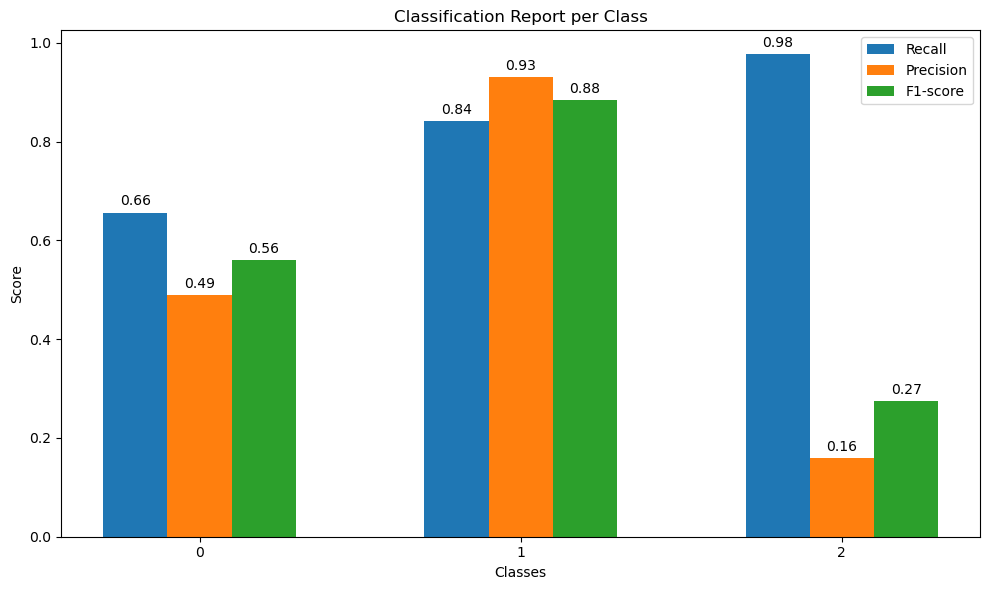

In [47]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the classification report as a dictionary
report = classification_report(test['Type'], test['pred'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()